[CpuDevice(id=0)]


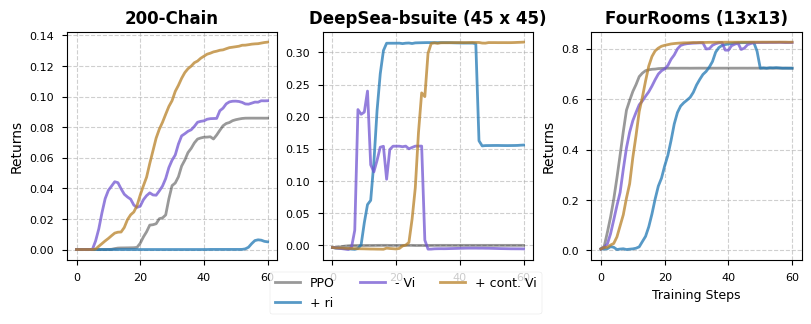

📁 Found ../figures/debug_results_with_cont.pdf (30.1 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import os
import json
import cloudpickle
import sys
sys.path.append(os.path.abspath(".."))
import os
os.environ["JAX_PLATFORMS"] = "cpu"
from IPython.display import FileLink, display, HTML
from mail import *
import jax
import jax.numpy as jnp
print(jax.devices())  # Should list CPU devices only
from plot_utils import plot_experiments, load_run_data, make_table
import matplotlib.pyplot as plt
import numpy as np

# List of environments for the 2x2 grid
envs = ['Chain', 'DeepSea-bsuite', 'FourRooms-misc']
env_names = ['200-Chain', 'DeepSea-bsuite (45 x 45)', 'FourRooms (13x13)']
# Use a professional style for conference papers
plt.style.use('seaborn-v0_8-paper') 
# Update params for tall aspect ratio as requested: 2x2 grid, slightly taller than wide
fig, axes = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
axes = axes.flatten()

# Store handles for the legend
handles, labels = [], []


for i, ENV in enumerate(envs):
    ax = axes[i]
    
    # Load data (Assuming load_run_data exists in your namespace)
    try:
        config, metrics = load_run_data('3_13_cov_lstd/intrinsic_reward_only', ENV)
        # config, opt_metrics = load_run_data('3_13_cov_lstd/plus_optimistic_init', ENV)
        # config, is_metrics = load_run_data('3_13_is_cov_lstd/plus_is', ENV)
        ppo_config, ppo_metrics = load_run_data('3_13_cov_lstd/baseline_ppo', ENV)
        config, ri_metrics = load_run_data('3_17_cov_no_vi/only_ri', ENV)
        config, cont_metrics = load_run_data('3_13_cov_lstd/continuing_no_opt', ENV)
        
        # Process PPO (Baseline)
        ppo_metrics_avg = jax.tree.map(lambda x: x.mean(0), ppo_metrics)
        ppo_rets = ppo_metrics_avg['returned_discounted_episode_returns']
        
        # Process SV-PPO
        sv_rets = metrics['returned_discounted_episode_returns'].mean(0)
        ri_rets = ri_metrics['returned_discounted_episode_returns'].mean(0)
        cont_rets = cont_metrics['returned_discounted_episode_returns'].mean(0)
        # opt_rets= opt_metrics['returned_discounted_episode_returns'].mean(0)
        # is_rets= is_metrics['returned_discounted_episode_returns'].mean(0)
        # 1. PPO Baseline
        l1, = ax.plot(ppo_rets, label='PPO', color='black', alpha=0.4, linewidth=2.0)
        
        # 2. SV-PPO Trace
        l2, = ax.plot(sv_rets, label='+ ri', color='#1f77b4', linewidth=2.0, alpha = 0.75)
        l3, = ax.plot(ri_rets, label='- Vi', color="#7154d1", linewidth=2.0, alpha = 0.75)
        l4, = ax.plot(cont_rets, label='+ cont. Vi', color="#b88027", linewidth=2.0, alpha = 0.75)
        
        # l3, = ax.plot(opt_rets, label='+ ri, opt. init', color="#7154d1", linewidth=2.0, alpha = 0.75)
        # l4, = ax.plot(is_rets, label='+ is', color="#c27c26", linewidth=2.0, alpha = 0.75)
        
        # Formatting
        ax.set_title(f'{env_names[i]}', fontweight='bold', fontsize=12)
        if i >= 2: ax.set_xlabel('Training Steps', fontsize=9)
        if i % 2 == 0: ax.set_ylabel('Returns', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Collect handles for the first plot to build the shared legend
        if i == 0:
            # handles = [l1, l2, l3, l4]
            handles = [l1, l2, l3, l4]
            labels = [h.get_label() for h in handles]
            
    except Exception as e:
        ax.text(0.5, 0.5, f"Data missing for\n{ENV}", ha='center')
        print(f"Error loading {ENV}: {e}")

# Consolidated Legend: Place at the bottom (or top) center
fig.legend(handles, labels, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, -0.05), frameon=True, fontsize=9)

# Adjust layout to make room for the legend at the bottom
plt.show()

# # To save for the paper:
fig.savefig('../figures/debug_results_with_cont.pdf', bbox_inches='tight', dpi=300)
email_pdf('../figures/debug_results_with_cont.pdf')

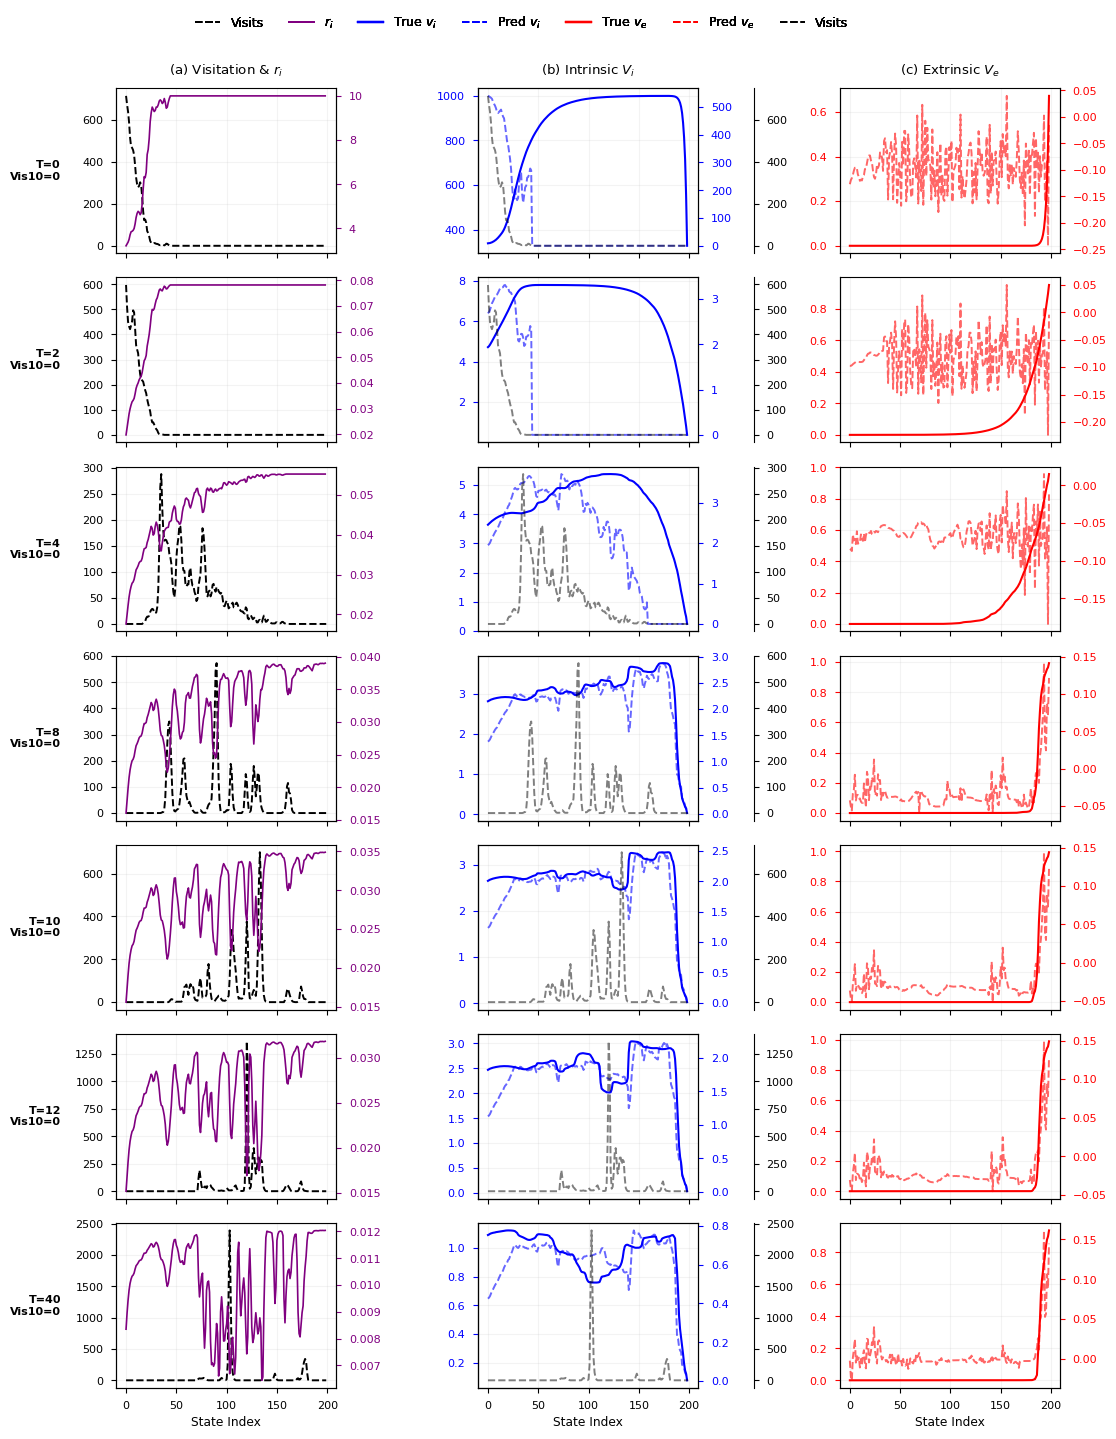

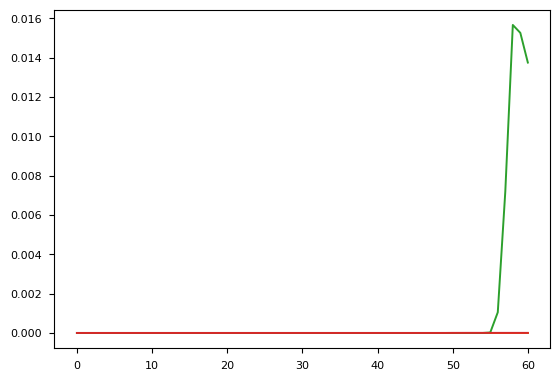

📁 Found ../figures/intrinsic_rew_on_chain.pdf (77.8 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [13]:
from plot_utils import plot_chain_visits_middle
fig = plot_chain_visits_middle('3_13_cov_lstd/intrinsic_reward_only', T_values=[0,2,4,8,10,12, 40] , SEED=1)

fig.savefig('../figures/intrinsic_rew_on_chain.pdf', bbox_inches='tight', dpi=300)
email_pdf('../figures/intrinsic_rew_on_chain.pdf')

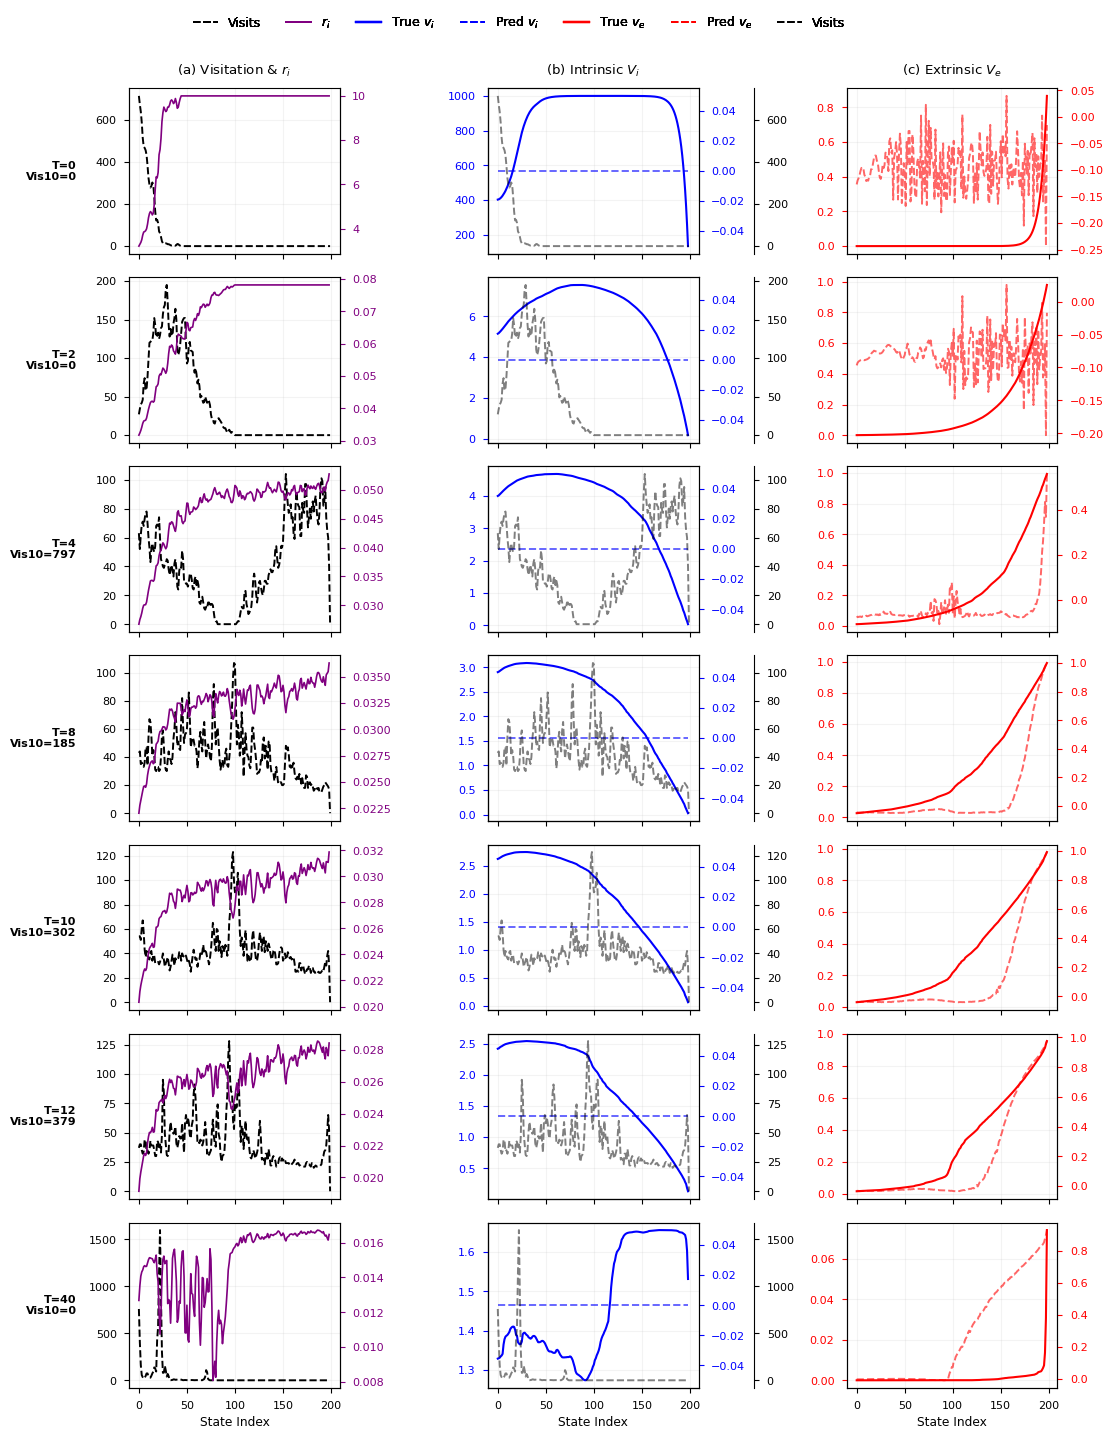

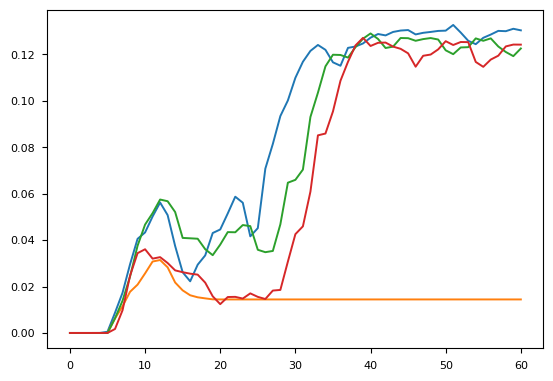

📁 Found ../figures/only_ri_chain.pdf (74.8 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [2]:
from plot_utils import plot_chain_visits_middle
fig = plot_chain_visits_middle('3_17_cov_no_vi/only_ri', T_values=[0,2,4,8,10,12, 40] , SEED=1)

fig.savefig('../figures/only_ri_chain.pdf', bbox_inches='tight', dpi=300)
email_pdf('../figures/only_ri_chain.pdf')

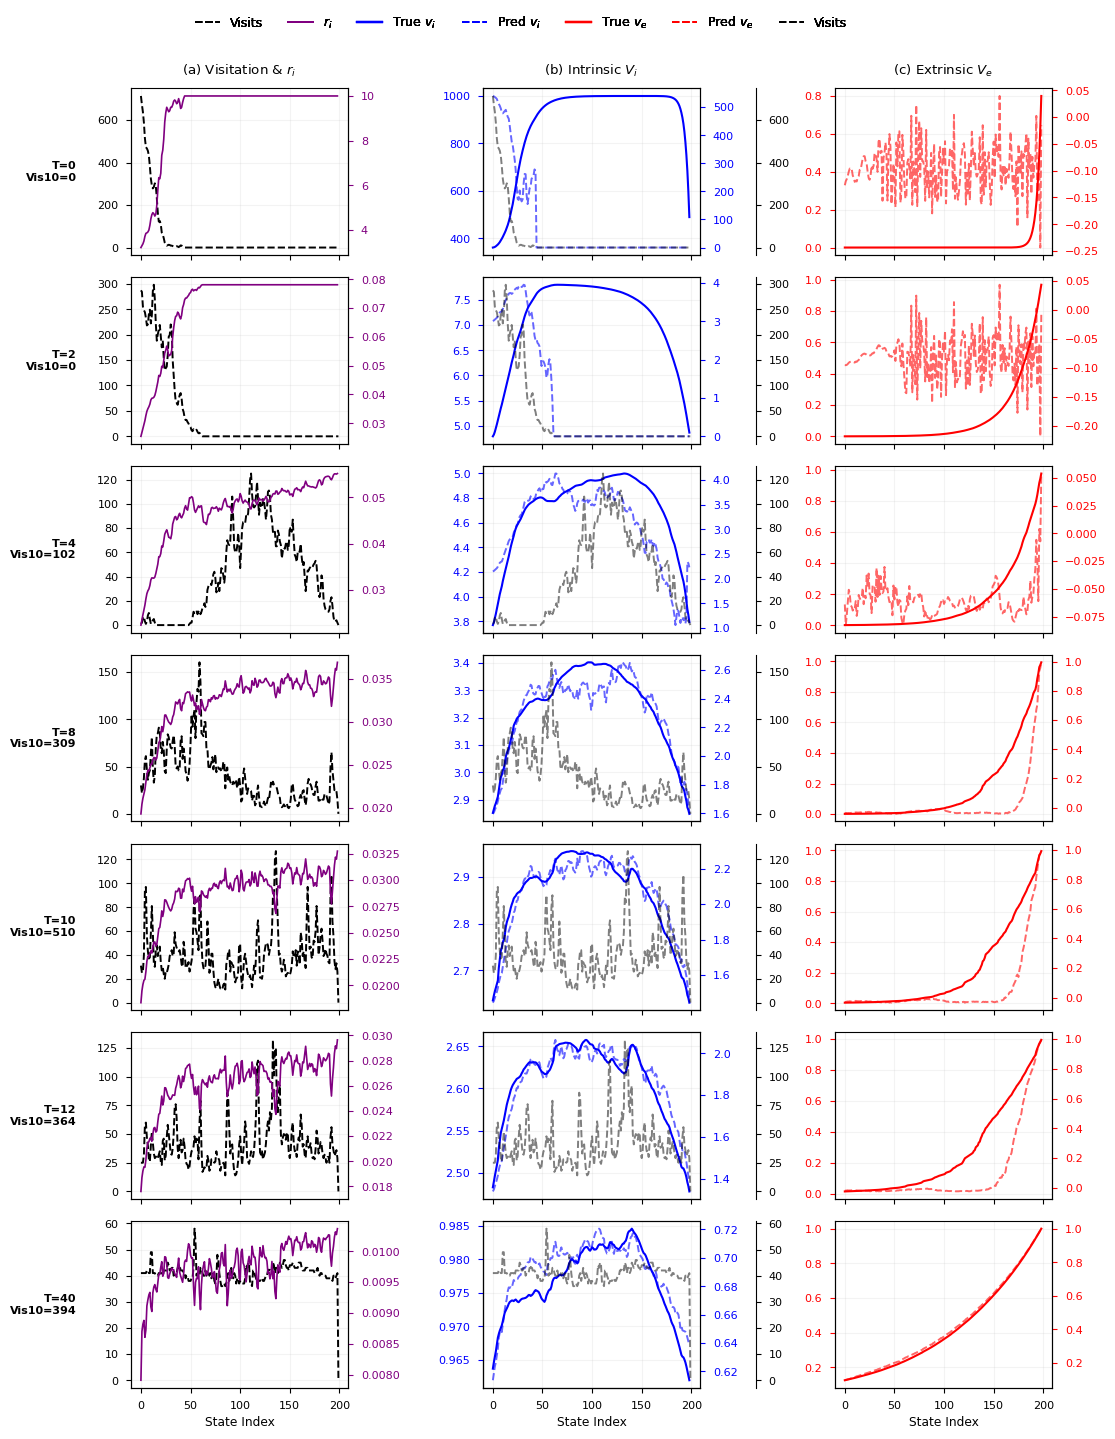

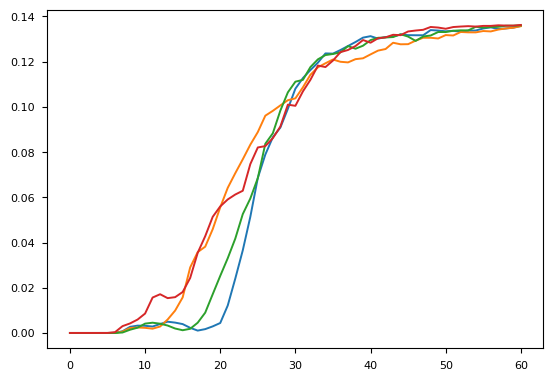

📁 Found ../figures/cont_chain.pdf (87.1 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [7]:
from plot_utils import plot_chain_visits_middle
fig = plot_chain_visits_middle('3_13_cov_lstd/continuing_no_opt', T_values=[0,2,4,8,10,12, 40] , SEED=1)

fig.savefig('../figures/cont_chain.pdf', bbox_inches='tight', dpi=300)
email_pdf('../figures/cont_chain.pdf')

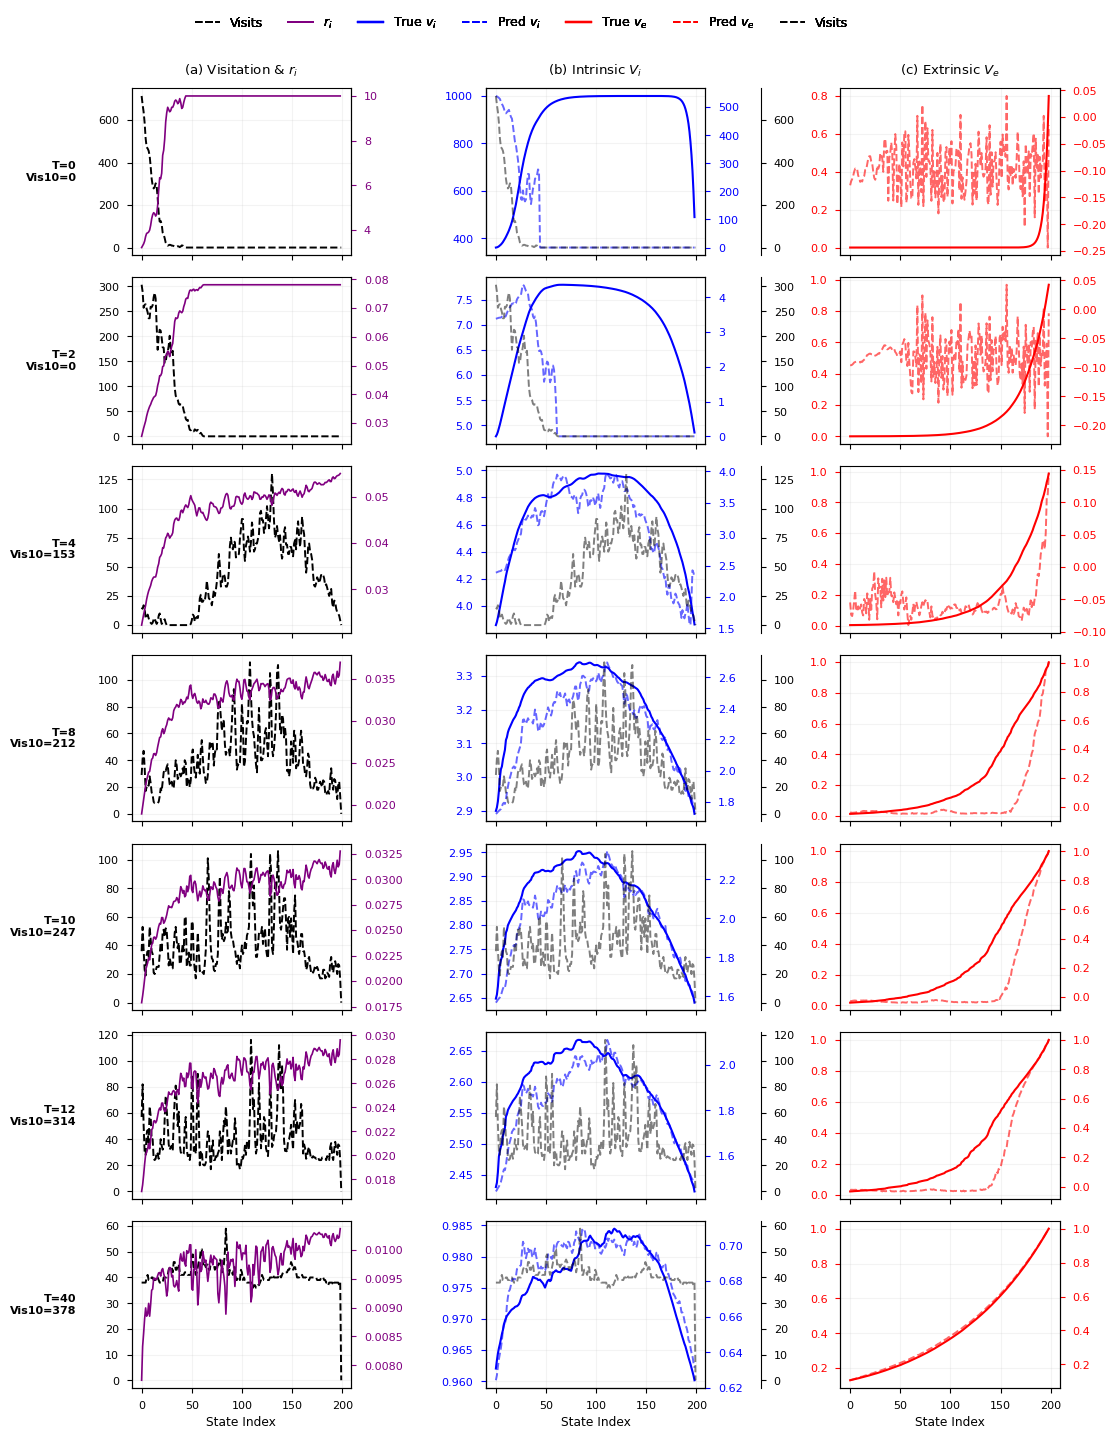

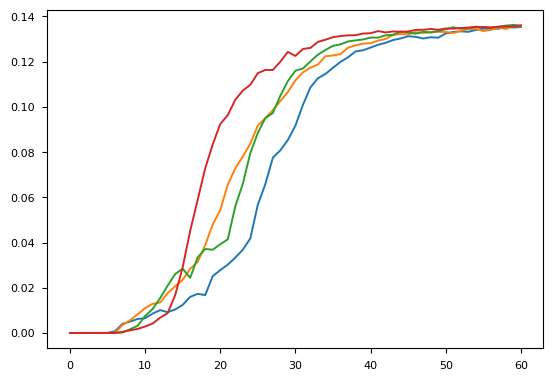

In [8]:
from plot_utils import plot_chain_visits_middle
fig = plot_chain_visits_middle('3_13_is_cov_lstd/continuing_no_opt', T_values=[0,2,4,8,10,12, 40] , SEED=1)

# fig.savefig('../figures/cont_chain.pdf', bbox_inches='tight', dpi=300)
# email_pdf('../figures/cont_chain.pdf')|